In [1]:
# =======================================================================================
#                       Etape 1 : Préparation et Transformation
# =======================================================================================

In [2]:
# ==================================
# 1. Importation des bibliothèques
# ==================================
from google.cloud import bigquery
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [3]:
# =========================================
# 3. Chargement et exploration des données
# =========================================
# Charger le dataset

client = bigquery.Client.from_service_account_json("key.json")

query = """
    SELECT
    *
    FROM `project-a0475dd2-d0c1-4640-aea.Sport_Metrics.mart_physical_condition`

"""

# Executer la requete
query_job = client.query(query)

# Transformer en dataframe
data = query_job.to_dataframe()

# Aperçu des premières lignes
print("Aperçu des données :\n", data.head())

# Informations générales sur les colonnes et les types de données
print("\nInformations sur le dataset :")
print(data.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
print(data.describe())

Aperçu des données :
       Season   player_id                        session_id  Next_Match_ID  \
0  2019-2020  1681114057  FFS_20191020_1681114057_21900010       21900010   
1  2019-2020  1684823847  FFS_20191021_1684823847_21900010       21900010   
2  2019-2020  1681114057  FFS_20191021_1681114057_21900010       21900010   
3  2019-2020  1679015727  FFS_20191021_1679015727_21900010       21900010   
4  2019-2020  1657985451  FFS_20191021_1657985451_21900010       21900010   

      player_name  fi_last_training  rs_last_training  \
0    Abdoulaye Ba             55.11              3.01   
1  Yanis Belkacem             55.33              1.10   
2    Abdoulaye Ba             56.88              2.06   
3  Bryan Fournier             58.30              2.08   
4   Pierre Martin             61.32              0.96   

   recovery_needed_last_training  Fi_before_match  Focus_Level  ...  fg3_pct  \
0                              0             0.00          8.0  ...    0.000   
1           

In [4]:
# ==================================
# 4. Gestion des valeurs manquantes
# ==================================
# Vérification des valeurs manquantes
print(data.isnull().sum())

Season                           0
player_id                        0
session_id                       0
Next_Match_ID                    0
player_name                      0
fi_last_training                 0
rs_last_training                 0
recovery_needed_last_training    0
Fi_before_match                  0
Focus_Level                      0
Strength_Score                   0
Shooting_Accuracy_pct            0
Passing_Accuracy_pct             0
Performance_Score                0
Load_Intensity_Score             0
Injury_Risk                      0
fi_avg_7d                        0
fi_max_7d                        0
training_load_7d                 0
fi_avg_28d                       0
fi_max_28d                       0
training_load_28d                0
Place                            0
Position                         0
Start_position                   0
minutes_played                   0
Points                           0
fg_pct                           0
fg3_pct             

In [5]:
# =======================================================================================
#                       Etape 2 : Machine Learning
# =======================================================================================

In [6]:
# Séparation des variables explicatives 'indépendantes' (X) et de la variable cible 'dépendante' (y)
X = data[['Shooting_Accuracy_pct']]
y = data['fg_pct'].values

# Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dimensions des ensembles :\nEntraînement : {X_train.shape}\nTest : {X_test.shape}")

Dimensions des ensembles :
Entraînement : (6004, 1)
Test : (1502, 1)


In [7]:
# ==============================
# 1. Régression linéaire simple
# ==============================

# Création du modèle
linear_model = LinearRegression()

# Ajustement du modèle
linear_model.fit(X_train, y_train)

# Prédictions
y_pred = linear_model.predict(X_test)

# Affichage des coefficients
print(f'Intercept (β0): {linear_model.intercept_}')
print(f'Coefficient (β1): {linear_model.coef_[0]}')

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Modèle linéaire :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

Intercept (β0): -0.3365854809201045
Coefficient (β1): 0.013988635307720116
Modèle linéaire :
Erreur quadratique moyenne (MSE): 0.0293
Coefficient de détermination (R²): 0.3721
Erreur absolue moyenne (MAE): 0.13


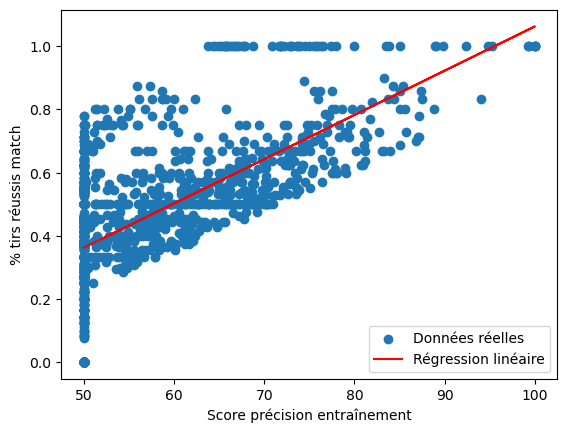

In [8]:
# Visualisation

plt.scatter(X_test, y_test, label='Données réelles')
plt.plot(X_test, y_pred, color='red', label='Régression linéaire')
plt.xlabel('Score précision entraînement')
plt.ylabel('% tirs réussis match')
plt.legend()
plt.show()

In [9]:
# =================================
# 2. Arbre de décision : Régression
# =================================

# Construction et ajustement de l'arbre de régression
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = tree_model.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Arbre de décision :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

Arbre de décision :
Erreur quadratique moyenne (MSE): 0.0283
Coefficient de détermination (R²): 0.3920
Erreur absolue moyenne (MAE): 0.13


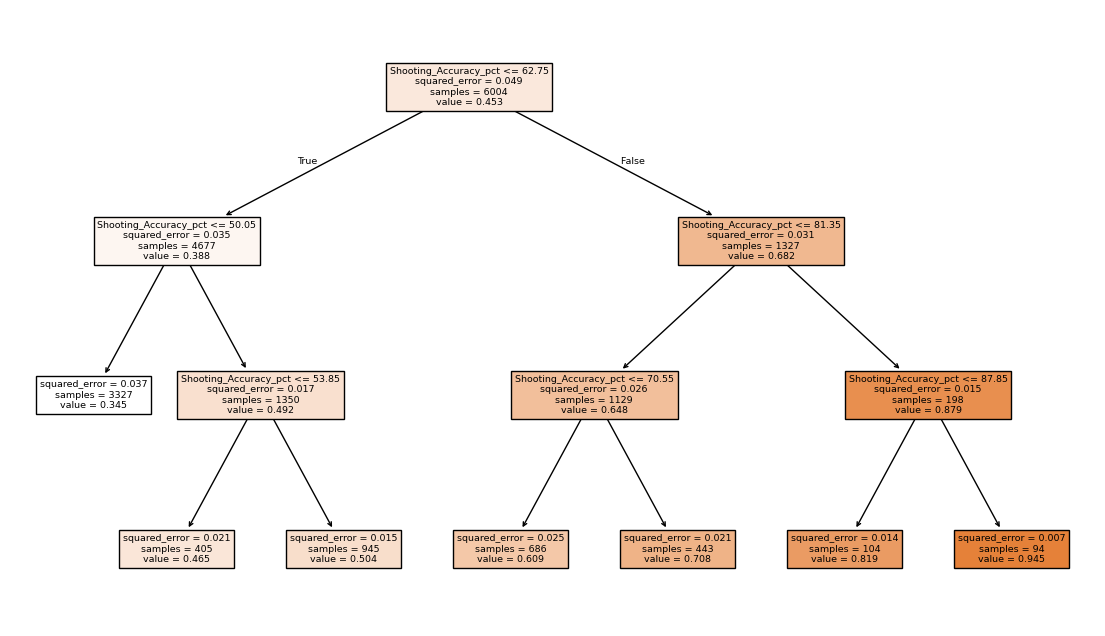

In [10]:
# Visualisation de l'arbre
plt.figure(figsize=(14, 8))
plot_tree(tree_model, feature_names=['Shooting_Accuracy_pct'], filled=True)
plt.show()

In [13]:
# =================================
# 3. Forêts aléatoires : Régression
# =================================

# Construction et ajustement de la forêt aléatoire
rf_model = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = rf_model.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Forêt aléatoire :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

Forêt aléatoire :
Erreur quadratique moyenne (MSE): 0.0288
Coefficient de détermination (R²): 0.3830
Erreur absolue moyenne (MAE): 0.13


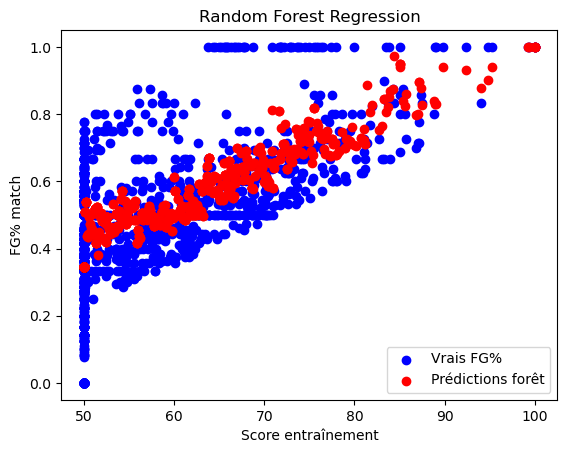

In [12]:
# Visualisation

plt.scatter(X_test['Shooting_Accuracy_pct'], y_test, color='blue', label='Vrais FG%')
plt.scatter(X_test['Shooting_Accuracy_pct'], y_pred, color='red', label='Prédictions forêt')
plt.xlabel('Score entraînement')
plt.ylabel('FG% match')
plt.title('Random Forest Regression')
plt.legend()
plt.show()

Conclusion:

On remarque que le modèle arbre atteint déjà la précision max (R² ≈ 0.39) avec un même MAE (MAE = 0.13) que le modèle de forêt, alors dans un soucis de minimiser l'impact technique (gain de productivité), pas besoin d'opter pour la forêt pour nos prédictions d'efficacité de tir . Le modèle de prédiction choisi sera le modèle Arbre.

La variation (écart) en tir étant de 39% (sous les 50%), cela implique qu'il existe d'autres facteurs qui agissent sur l'adresse au tir en match (fatigue, Focus, Pression, ...)